In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"
import requests

In [6]:
#211
#198
#124
#335

id = 335

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf

,geometry,Средняя этажность,Численность населения,Плотность населения,Площадь территории,Оценка по каркасу расселения,Население,Экологическая ситуация,Потенциал размещения порта,Социальное обеспечение,...,Потенциал развития жилой застройки типа ИЖС,Потенциал развития малоэтажной жилой застройки,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки общественно-деловой зоны,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки транспортной зоны
0,"MULTIPOLYGON (((329788.882 6583309.434, 330250...",2.0,0.0,0.0,789.4,5.0,4.0,-1.91,2.01,3.6,...,2.0,3.0,3.0,1.0,2.0,4.0,5.0,4.0,3.0,5.0


In [7]:
project_id = 72
params = {
    "year": 2024,
    "source": "OSM"
}

territory_context_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/context/functional_zones",
    params=params
)

if territory_context_response.status_code != 200:
    raise Exception("Ошибка при получении геометрии территории")

territory_data = territory_context_response.json()

# Проверяем, что структура — FeatureCollection
if "features" not in territory_data:
    raise Exception("Ожидалась структура FeatureCollection с ключом 'features'")

# Преобразуем все features в GeoDataFrame
polygon_context_gdf = gpd.GeoDataFrame.from_features(territory_data["features"], crs=4326)
polygon_context_gdf = polygon_context_gdf.to_crs(32636)

polygon_context_gdf


,geometry,functional_zone_id,territory,functional_zone_type,name,year,source,properties,created_at,updated_at
0,"MULTILINESTRING ((321251.598 6586893.964, 3212...",13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z
1,"MULTIPOLYGON (((329762.995 6583666.356, 329747...",15086,"{'id': 67, 'name': 'Гатчинский муниципальный р...","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-12-01T17:49:03.818426Z,2024-12-01T17:49:03.818426Z
2,"POLYGON ((335568.363 6584915.953, 335568.559 6...",15072,"{'id': 2124, 'name': 'деревня Старосиверская'}","{'id': 4, 'name': 'industrial', 'nickname': 'П...",None,2024,OSM,{'landuse_zon': 'Industrial'},2024-12-01T17:49:02.360089Z,2024-12-01T17:49:02.360089Z
3,"POLYGON ((334732.201 6585463, 334792.603 65853...",15230,"{'id': 2124, 'name': 'деревня Старосиверская'}","{'id': 7, 'name': 'business', 'nickname': 'Общ...",None,2024,OSM,{'landuse_zon': 'Business'},2024-12-01T17:49:17.530799Z,2024-12-01T17:49:17.530799Z
4,"POLYGON ((338747.147 6580055.547, 338703.328 6...",15194,"{'id': 82, 'name': 'Сиверское городское поселе...","{'id': 1, 'name': 'residential', 'nickname': '...",None,2024,OSM,{'landuse_zon': 'Residential'},2024-12-01T17:49:14.414830Z,2024-12-01T17:49:14.414830Z
...,...,...,...,...,...,...,...,...,...,...
1304,"MULTIPOLYGON (((330868.533 6582135.168, 330876...",110673,"{'id': 2230, 'name': 'деревня Межно'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-11T14:22:07.328299Z,2024-12-11T14:22:07.328299Z
1305,"POLYGON ((329915.602 6569460.846, 329904.035 6...",123885,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-12-17T16:22:38.444659Z,2024-12-17T16:22:38.444659Z
1306,"POLYGON ((321249.514 6570566.852, 321259.932 6...",123982,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:31:55.771201Z,2024-12-17T16:31:55.771201Z
1307,"MULTILINESTRING ((322841.531 6571307.529, 3228...",124034,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:37:10.453153Z,2024-12-17T16:37:10.453153Z


In [9]:
# Преобразование мультиполигонов в отдельные полигоны
polygon_context_gdf = polygon_context_gdf.explode(index_parts=False)

# Сброс индекса
polygon_context_gdf = polygon_context_gdf.reset_index(drop=True)
polygon_context_gdf

,functional_zone_id,territory,functional_zone_type,name,year,source,properties,created_at,updated_at,geometry
0,13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z,"LINESTRING (321251.598 6586893.964, 321221.896..."
1,13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z,"LINESTRING (321314.004 6586906.628, 321251.598..."
2,13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z,"LINESTRING (321453.278 6586899.045, 321314.004..."
3,13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z,"LINESTRING (321561.058 6586897.747, 321453.278..."
4,13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z,"LINESTRING (322113.398 6586891.143, 321561.058..."
...,...,...,...,...,...,...,...,...,...,...
3644,123885,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-12-17T16:22:38.444659Z,2024-12-17T16:22:38.444659Z,"POLYGON ((329915.602 6569460.846, 329904.035 6..."
3645,123982,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:31:55.771201Z,2024-12-17T16:31:55.771201Z,"POLYGON ((321249.514 6570566.852, 321259.932 6..."
3646,124034,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:37:10.453153Z,2024-12-17T16:37:10.453153Z,"LINESTRING (322841.531 6571307.529, 322831.296..."
3647,124034,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:37:10.453153Z,2024-12-17T16:37:10.453153Z,"LINESTRING (322841.531 6571307.529, 322842.811..."


In [ ]:
# for col in polygon_gdf.columns:
#     unique_vals = polygon_gdf[col].unique()
#     print(f"Атрибут: {col}")
#     print(f"Значения: {unique_vals}\n")


In [1]:
# Выводим имена столбцов, где хотя бы одно значение попадает в диапазон от -5 до 5, исключая 0
attributes_in_range = [
    col for col in polygon_gdf.columns
    if polygon_gdf[col].dtype.kind in 'if'  # Только числовые столбцы (int, float)
    and (((polygon_gdf[col] >= -5) & (polygon_gdf[col] <= 5) & (polygon_gdf[col] != 0)).any())
]

for col in attributes_in_range:
    unique_vals = polygon_gdf[col].unique()
    print(f"Атрибут: {col}")
    print(f"Значения: {unique_vals}\n")




NameError: name 'polygon_gdf' is not defined

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_4744/3801394392.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


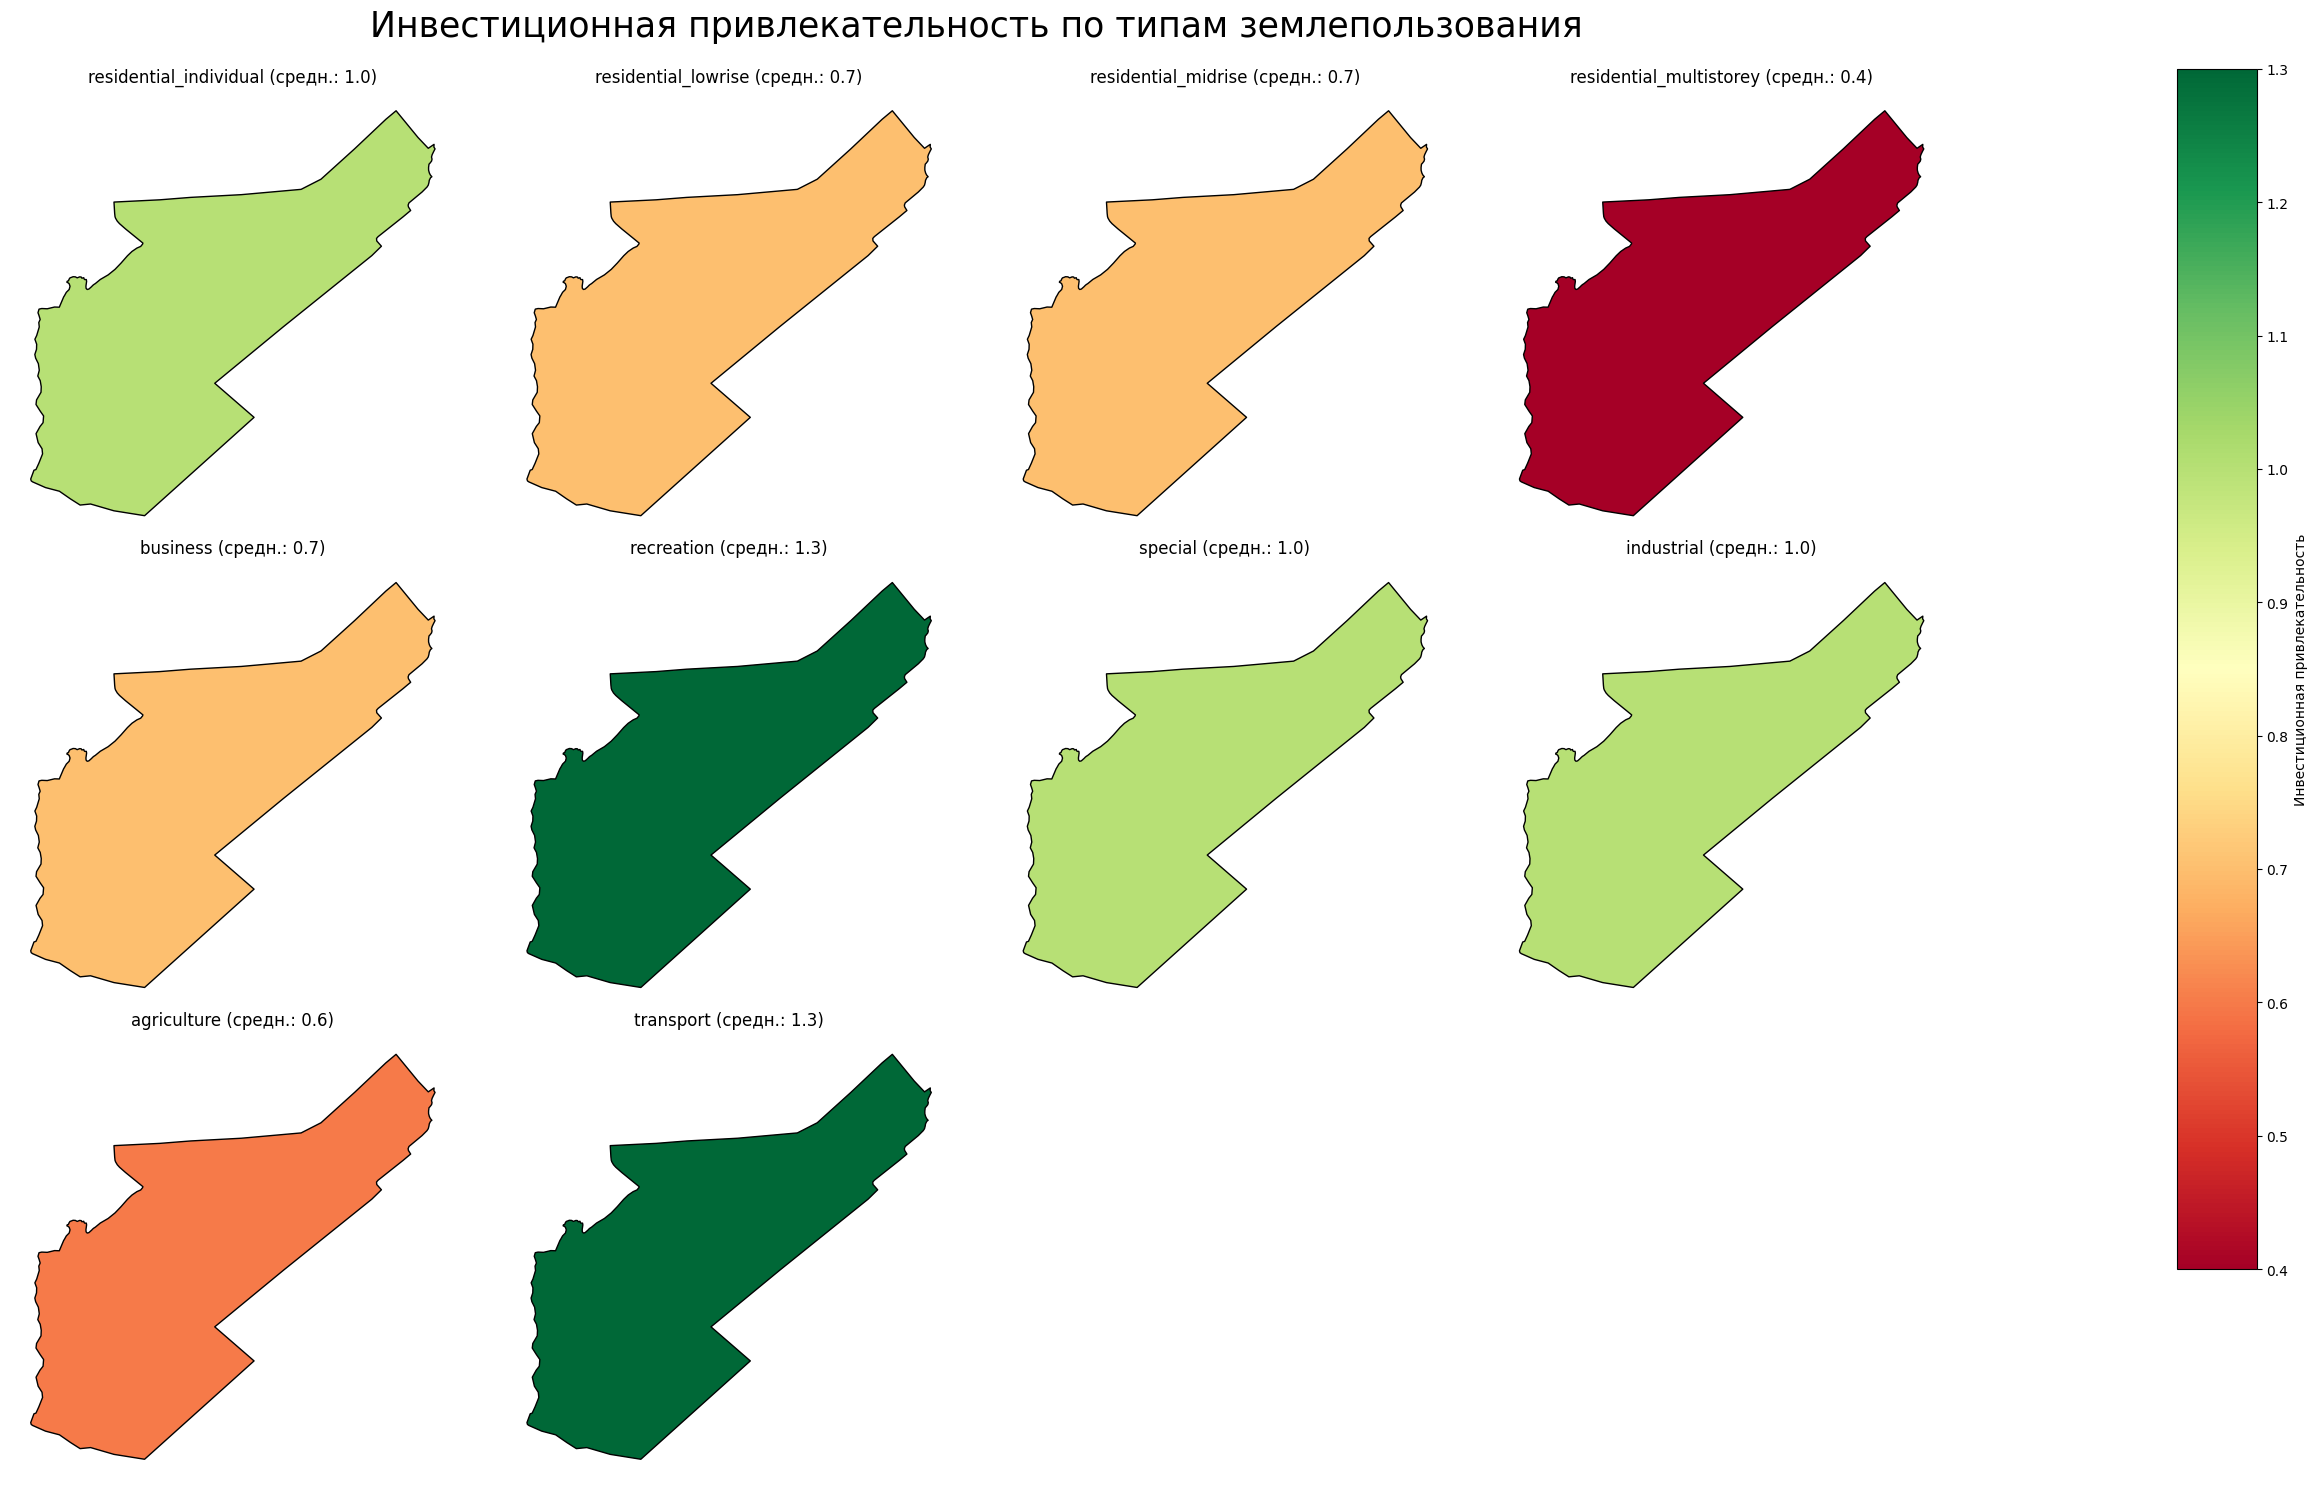

In [13]:
import matplotlib.pyplot as plt
import math
import pandas as pd

# Карта соответствия land use → колонка с потенциалом
land_use_to_potential_column = {
    'residential_individual': 'Потенциал развития жилой застройки типа ИЖС',
    'residential_lowrise': 'Потенциал развития малоэтажной жилой застройки',
    'residential_midrise': 'Потенциал развития среднеэтажной жилой застройки',
    'residential_multistorey': 'Потенциал развития многоэтажной жилой застройки',
    'business': 'Потенциал развития застройки общественно-деловой зоны',
    'recreation': 'Потенциал развития застройки рекреационной зоны',
    'special': 'Потенциал развития застройки зоны специального назначения',
    'industrial': 'Потенциал развития застройки промышленной зоны',
    'agriculture': 'Потенциал развития застройки сельскохозяйственной зоны',
    'transport': 'Потенциал развития застройки транспортной зоны'
}

weights = {
    'residential_individual': {
        'Население': 1.3,  # Умеренная плотность важна для ИЖС
        'Социальное обеспечение': 1.4,  # Инфраструктура критична для жизни
        'Экологическая ситуация': 1.5,  # Чистая среда важна для частных домов
        'Средняя доступность до близлежащего крупного населенного пункта': 1.2,  # Близость к городу
        'Транспортное обеспечение': 1.1,  # Удобство поездок
        'default': 1.0
    },
    'residential_lowrise': {
        'Население': 1.4,  # Нужна достаточная плотность для малоэтажки
        'Социальное обеспечение': 1.3,  # Инфраструктура важна
        'Экологическая ситуация': 1.4,  # Комфортная среда
        'Транспортное обеспечение': 1.2,  # Доступность
        'default': 1.0
    },
    'residential_midrise': {
        'Средняя этажность': 1.5,  # Соответствие существующей застройке
        'Население': 1.4,  # Плотность для среднеэтажных домов
        'Социальное обеспечение': 1.3,  # Услуги для жителей
        'Транспортное обеспечение': 1.2,  # Связь с городом
        'default': 1.0
    },
    'residential_multistorey': {
        'Средняя этажность': 1.5,  # Подходит для высотной застройки
        'Население': 1.4,  # Высокая плотность для многоэтажек
        'Транспортное обеспечение': 1.3,  # Критично для больших жилых зон
        'Социальное обеспечение': 1.2,  # Базовые услуги
        'default': 1.0
    },
    'business': {
        'Транспортное обеспечение': 1.5,  # Доступность для клиентов и сотрудников
        'Население': 1.4,  # Потребительская база
        'Социальное обеспечение (комфорт)': 1.3,  # Привлекательность для бизнеса
        'Средняя доступность до близлежащего крупного населенного пункта': 1.2,  # Близость к рынкам
        'default': 1.0
    },
    'recreation': {
        'Экологическая ситуация': 1.5,  # Чистая природа — ключевой фактор
        'Социальное обеспечение (комфорт)': 1.4,  # Удобства для отдыха
        'Транспортное обеспечение': 1.2,  # Доступность для посетителей
        'Население': 0.8,  # Высокая плотность может мешать
        'default': 1.0
    },
    'special': {
        'Потенциал размещения порта': 1.5,  # Основной фактор для спецзон
        'Транспортное обеспечение': 1.4,  # Логистика важна
        'Потенциал размещения логистического, складского комплекса': 1.3,  # Дополнительная поддержка
        'default': 1.0
    },
    'industrial': {
        'Потенциал размещения логистического, складского комплекса': 1.5,  # Ключевая инфраструктура
        'Транспортное обеспечение': 1.4,  # Доставка сырья и продукции
        'Экологическая ситуация': 0.8,  # Промзоны менее требовательны к экологии
        'Население': 0.9,  # Высокая плотность может быть помехой
        'default': 1.0
    },
    'agriculture': {
        'Экологическая ситуация': 1.5,  # Качество среды для сельского хозяйства
        'Население': 0.8,  # Высокая плотность снижает доступность земли
        'Транспортное обеспечение': 1.2,  # Доставка продукции
        'Средняя доступность до близлежащего крупного населенного пункта': 1.1,  # Рынки сбыта
        'default': 1.0
    },
    'transport': {
        'Потенциал размещения логистического, складского комплекса': 1.5,  # Логистика критична
        'Количество аэропортов местного значения': 1.4,  # Поддержка авиации
        'Средняя доступность до близлежащего крупного населенного пункта': 1.3,  # Связь с центрами
        'default': 1.0
    }
}

def plot_attribute_weights(weights_dict, land_use_key, ax):
    weights_for_lu = weights_dict[land_use_key].copy()
    weights_for_lu.pop('default', None)
    
    # Разделение на сильные (>1) и слабые (<1) стороны
    strong = {k: v for k, v in weights_for_lu.items() if v > 1}
    weak = {k: v for k, v in weights_for_lu.items() if v < 1}

    # Объединение для единой сортировки
    all_weights = {**strong, **weak}
    sorted_items = sorted(all_weights.items(), key=lambda x: x[1], reverse=True)

    labels, values = zip(*sorted_items)
    colors = ['green' if v > 1 else 'red' for v in values]

    ax.barh(labels, values, color=colors)
    ax.set_xlim(0, max(values) + 0.5)
    ax.set_title(f'Влияние факторов: {land_use_key}', fontsize=10)
    ax.invert_yaxis()  # чтобы важные сверху


# Исключаем потенциалы из расчёта
potential_cols = list(land_use_to_potential_column.values())

# Только числовые столбцы без потенциалов, в пределах от -5 до 5, и не равные 0
attributes_in_range = [
    col for col in polygon_gdf.columns
    if polygon_gdf[col].dtype.kind in 'if'
    and col not in potential_cols
    and (((polygon_gdf[col] >= -5) & (polygon_gdf[col] <= 5) & (polygon_gdf[col] != 0)).any())
]

# Вычисление инвестиционной привлекательности с учётом весов
for land_use, potential_col in land_use_to_potential_column.items():
    polygon_gdf[f'ИП_{land_use}'] = polygon_gdf.apply(
        lambda row: round(
            (
                sum([row[attr] * weights[land_use].get(attr, weights[land_use]['default']) 
                     for attr in attributes_in_range if pd.notna(row[attr])]) /
                len([row[attr] for attr in attributes_in_range if pd.notna(row[attr])])
            ) * (row[potential_col] / 5), 1
        ) if pd.notna(row[potential_col]) else None,
        axis=1
    )

# Список столбцов с результатами
score_cols = [f'ИП_{lu}' for lu in land_use_to_potential_column]

# Границы цвета
vmin = polygon_gdf[score_cols].min().min()
vmax = polygon_gdf[score_cols].max().max()

# Сетка графиков
n = len(land_use_to_potential_column)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

# Отрисовка каждой карты
for i, (land_use, ax) in enumerate(zip(land_use_to_potential_column.keys(), axes)):
    col = f'ИП_{land_use}'
    mean_val = polygon_gdf[col].mean()

    polygon_gdf.plot(
        column=col,
        cmap='RdYlGn',
        legend=False,
        ax=ax,
        edgecolor='black',
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{land_use} (средн.: {mean_val:.1f})", fontsize=12)
    ax.axis('off')

# Удаление пустых осей
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Общая цветовая шкала
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([1.1, 0.15, 0.04, 0.8])
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
fig.colorbar(sm, cax=cax, label='Инвестиционная привлекательность')

plt.suptitle("Инвестиционная привлекательность по типам землепользования", fontsize=25, y=0.99)
plt.tight_layout()
plt.show()